In [2]:
sentence = ["The", "cat", "sat", "on", "the", "mat"]

attention_scores = {"The": 0.1,
                    "cat": 1.0,
                    "sat": 0.8,
                    "on": 0.3,
                    "the": 0.1,
                    "mat": 0.6}

In [4]:
word_vectors = {"The": [0.1, 0.2, 0.3],
                "cat": [0.5, 0.8, 0.2],
                "sat": [0.7, 0.1, 0.9],
                "on": [0.2, 0.6, 0.3],
                "the": [0.1, 0.2, 0.3],
                "mat": [0.8, 0.3, 0.5]}

new_vector = []
for dim in range(3):
    weighted_sum = (0.1 * word_vectors["The"][dim] +
                    1.0 * word_vectors["cat"][dim] +
                    0.8 * word_vectors["sat"][dim] +
                    0.3 * word_vectors["on"][dim] +
                    0.1 * word_vectors["the"][dim] +
                    0.6 * word_vectors["mat"][dim])
    new_vector.append(weighted_sum)

print(word_vectors["cat"])
print(new_vector)

[0.5, 0.8, 0.2]
[1.6199999999999999, 1.28, 1.37]


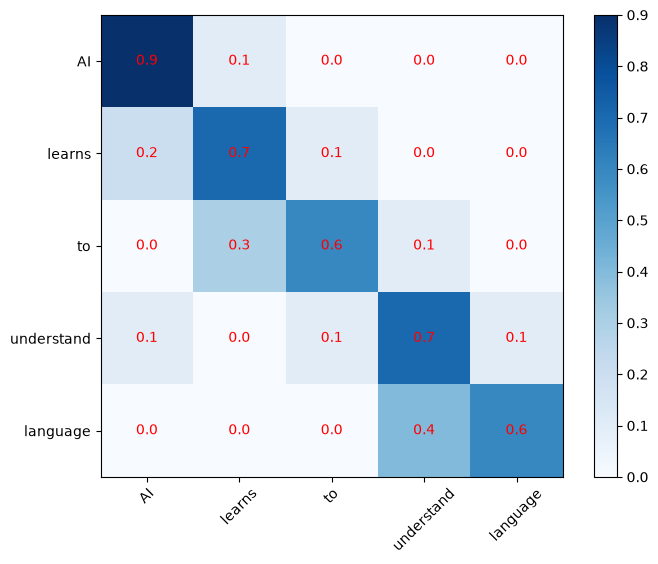

In [5]:
import matplotlib.pyplot as plt
import numpy as np

words = ["AI", "learns", "to", "understand", "language"]

attention_matrix = np.array([[0.9, 0.1, 0.0, 0.0, 0.0],
                             [0.2, 0.7, 0.1, 0.0, 0.0],
                             [0.0, 0.3, 0.6, 0.1, 0.0],
                             [0.1, 0.0, 0.1, 0.7, 0.1],
                             [0.0, 0.0, 0.0, 0.4, 0.6]])

plt.figure(figsize = (8, 6))
plt.imshow(attention_matrix, cmap = "Blues")
plt.xticks(range(len(words)), words, rotation = 45)
plt.yticks(range(len(words)), words)
plt.colorbar()

for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f"{attention_matrix[i, j]:.1f}",
                 ha = "center",
                 va = "center",
                 color = "red")

plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

class SelfAttentionExplainer:
    def __init__(self, d_model = 512):
        self.d_model = d_model
    def step_by_step_attention(self, sentence):
        words = sentence.split()
        vocab_size = len(words)
        embeddings = torch.randn(vocab_size, self.d_model)
        for i, word in enumerate(words):
            print(word, embeddings[i][:5].tolist())

        W_q = torch.randn(self.d_model, self.d_model)
        W_k = torch.randn(self.d_model, self.d_model)
        W_v = torch.randn(self.d_model, self.d_model)

        Q = embeddings @ W_q
        K = embeddings @ W_k
        V = embeddings @ W_v

        print(Q.shape)
        print(K.shape)
        print(V.shape)

        scores = Q @ K.T / np.sqrt(self.d_model)
        print(scores.shape)

        attention_weights = F.softmax(scores, dim = 1)

        plt.figure(figsize = (10, 8))
        plt.imshow(attention_weights.detach().numpy(), cmap = "Blues")
        plt.xticks(range(len(words)), words, rotation = 45)
        plt.yticks(range(len(words)), words)
        plt.colorbar()

        for i in range(len(words)):
            for j in range(len(words)):
                plt.text(j, i, f"{attention_weights[i, j]:.2f}",
                         ha = "center",
                         va = "center",
                         color = "red" if attention_weights[i, j] > 0.3 else "black")
        plt.tight_layout()
        plt.show()

        output = attention_weights @ V
        print(output.shape)

        for i, word in enumerate(words):
            top_attention = torch.argmax(attention_weights[i])
            top_word = words[top_attention]
            top_score = attention_weights[i, top_attention].item()
        return output, attention_weights

In [8]:
def run_attention_demo():
    explainer = SelfAttentionExplainer()
    sentences = ["The cat sat on the mat",
                 "AI learns to understand language",
                 "Transformer models revolutionized NLP"]
    for sentence in sentences:
        output, weights = explainer.step_by_step_attention(sentence)

In [9]:
class PracticalAttentionExample:
    def __init__(self):
        self.multihead_attn = nn.MultiheadAttention(embed_dim = 512,
                                                    num_heads = 8,
                                                    batch_first = True)
    def text_classification_with_attention(self):
        batch_size, seq_len, embed_dim = 2, 10, 512
        text_embeddings = torch.randn(batch_size, seq_len, embed_dim)
        attn_output, attn_weights = self.multihead_attn(text_embeddings,
                                                        text_embeddings,
                                                        text_embeddings)
        print(text_embeddings.shape)
        print(attn_output.shape)
        print(attn_weights.shape)

        classifier = nn.Sequential(nn.Linear(embed_dim, 256),
                                   nn.ReLU(),
                                   nn.Dropout(0.1),
                                   nn.Linear(256, 3)) # 3인 이유 긍정, 부정, 중립(뉴트럴) 에 대한 분류도 함께
        pooled = attn_output.mean(dim = 1)
        predictions = classifier(pooled)
        print(predictions.shape)
        return predictions

The [0.13431990146636963, 0.39729180932044983, -0.008501287549734116, -0.7158112525939941, 2.3957180976867676]
cat [-0.4550916850566864, -1.2481839656829834, 0.20644959807395935, 1.1041353940963745, -0.43677330017089844]
sat [-0.21055130660533905, -1.0007317066192627, -0.05966195836663246, -2.0990705490112305, 0.2494521290063858]
on [0.5899895429611206, -1.1202335357666016, 0.6181522607803345, 0.42207714915275574, -2.596743583679199]
the [-0.11557374894618988, 0.06982602924108505, 0.6228210926055908, -1.4536515474319458, 0.26949161291122437]
mat [0.5157833099365234, -0.43185850977897644, 0.4780210256576538, -2.222865581512451, -0.38278093934059143]
torch.Size([6, 512])
torch.Size([6, 512])
torch.Size([6, 512])
torch.Size([6, 6])


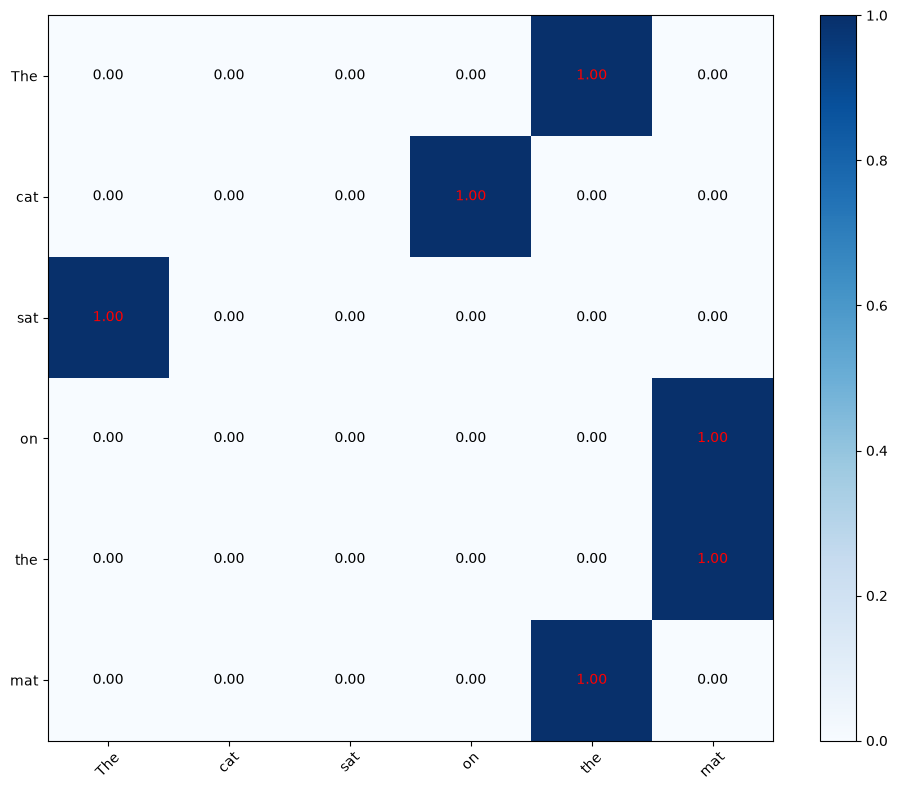

torch.Size([6, 512])
AI [-0.2487216740846634, 2.284478187561035, 1.1261248588562012, 0.26345664262771606, 1.661840558052063]
learns [1.5336298942565918, -0.38812053203582764, 0.3031309247016907, -0.49033647775650024, -0.7306811213493347]
to [-1.1741863489151, -0.19800685346126556, 0.9867490530014038, -0.21148306131362915, -0.06857088208198547]
understand [1.0550544261932373, 0.3678111135959625, -0.10883639007806778, 0.6122209429740906, -0.14376544952392578]
language [0.41332918405532837, -0.3027709722518921, 0.6247376799583435, 2.0173966884613037, -0.6212518811225891]
torch.Size([5, 512])
torch.Size([5, 512])
torch.Size([5, 512])
torch.Size([5, 5])


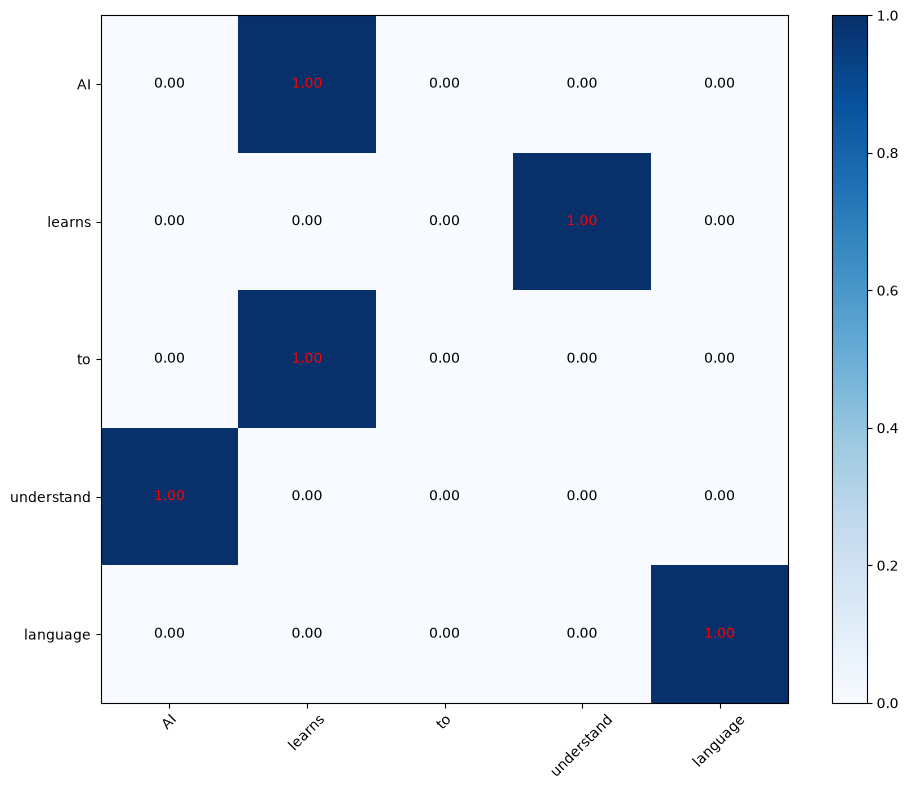

torch.Size([5, 512])
Transformer [-0.039616312831640244, 0.7273469567298889, 0.2879033088684082, -1.4334187507629395, 1.0155161619186401]
models [0.22809818387031555, -1.298868179321289, 1.1442127227783203, 1.0112547874450684, 1.0036011934280396]
revolutionized [-0.08806894719600677, -1.0731700658798218, 0.8258935809135437, 0.8879985213279724, 0.046767085790634155]
NLP [-0.8537139892578125, -0.19459322094917297, 0.05400684475898743, -0.8486154675483704, 0.2738734483718872]
torch.Size([4, 512])
torch.Size([4, 512])
torch.Size([4, 512])
torch.Size([4, 4])


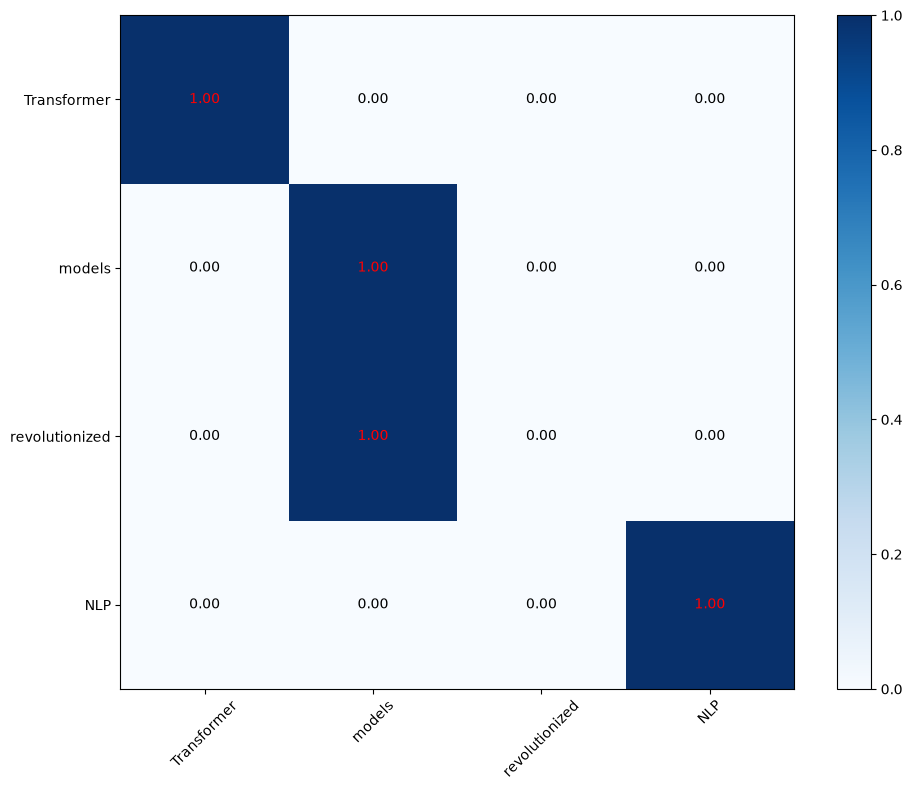

torch.Size([4, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 10])
torch.Size([2, 3])


tensor([[ 0.0025,  0.0132,  0.0721],
        [-0.0593, -0.0393, -0.0068]], grad_fn=<AddmmBackward0>)

In [10]:
run_attention_demo()

practical = PracticalAttentionExample()
practical.text_classification_with_attention()

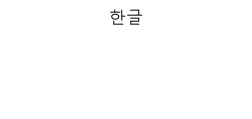

In [13]:
# transformer 구조에 대해 확인
# 인코더 / 디코더 존재 문장을 벡터로 / 벡터를 문장으로
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize = (3, 1))
plt.title("한글")
plt.axis("off")
plt.show()

In [15]:
# BERT를 이용하여 사용하는 법

from transformers import BertTokenizer, BertForSequenceClassification
import torch

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = 2)

sentence = "This movie was fantastic!"
inputs = tokenizer(sentence,
                   return_tensors = "pt",
                   truncation = True,
                   padding = True)
outputs = model(**inputs)
logits = outputs.logits
predicted_class = torch.argmax(logits, dim = 1)
print(predicted_class.item())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


1


In [19]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sentences = ["I love this movie",
             "I hate this movie",
             "It was okay",
             "Fantastic film",
             "Terrible experience"]
labels = torch.tensor([1, 0, 1, 1, 0])

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
encoded_inputs = tokenizer(sentences,
                           padding = True,
                           return_tensors = "pt")
dataset = TensorDataset(encoded_inputs["input_ids"], labels)
train_loader = DataLoader(dataset, batch_size = 2, shuffle = True)

model_fe = BertForSequenceClassification.from_pretrained("bert-base-uncased",
                                                         num_labels = 2)
for param in model_fe.bert.parameters():
    param.requires_grad = False
optimizer_fe = optim.Adam(model_fe.parameters(), lr = 2e-5)

model_ft = BertForSequenceClassification.from_pretrained("bert-base-uncased",
                                                         num_labels = 2)
optimizer_ft = optim.Adam(model_ft.parameters(), lr = 2e-5)

def train_model(model, optimizer, epochs = 3):
    model.train()
    for epoch in range(epochs):
        for input_ids, label in train_loader:
            optimizer.zero_grad()
            outputs = model(input_ids = input_ids, labels = label)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

train_model(model_fe, optimizer_fe)
train_model(model_ft, optimizer_ft)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
# ResNet을 활용한 전이학습

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image

resnet18 = models.resnet18(pretrained = True)
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 10)

resnet18.eval()

transform = transforms.Compose([transforms.Resize((224, 224)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean = [0.485, 0.456, 0.406],
                                                     std = [0.229, 0.224, 0.225])])
img = Image.open("example.jpg").convert("RGB")
img_t = transform(img)
img_t = img_t.unsqueeze(0)
outputs = resnet18(img_t)
_, predicted = torch.max(outputs, 1)
print(predicted.item())

c:\Users\KDT-17\Documents\17-DeepLearning\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\KDT-17\Documents\17-DeepLearning\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


8


In [18]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = 2)

sentence = "Today is a fucking sleepy day!"
inputs = tokenizer(sentence,
                   return_tensors = "pt",
                   truncation = True,
                   padding = True)
outputs = model(**inputs)
logits = outputs.logits
predicted_class = torch.argmax(logits, dim = 1)
print(predicted_class.item())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0
